Load models from Bradley-Terry/ModelPool with VAE Support

In [9]:

# GPU 和环境配置
import os
os.environ["PYTORCH_DISABLE_DYNAMO"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch

# 禁用 torch 编译功能
torch._dynamo.config.disable = True
torch._dynamo.config.suppress_errors = True

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Current GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 导入必要的库
from CatanSimulator import RunGame
import random
import torch.nn as nn
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from DeepLearning.Environments.DummyEnv import DummyEnv
from DeepLearning.CustomMaskablePPO import MaskablePPO
from Agents.AgentRandom2 import AgentRandom2
from Agents.AgentUCT import AgentUCT
from Agents.AgentModel import AgentMultiModel
from DeepLearning.Encoders.MainGame.Observation.get_observation_full import getObservationFull
from DeepLearning.Encoders.MainGame.ActionMask.GetActionMask import getActionMask
from DeepLearning.Encoders.Setup.ActionMask.getSetupActionMask import getSetupActionMask
from DeepLearning.Encoders.Setup.Observation.getObservationSetup import getObservationSetup

agent_list = ["UCT100"]

# VAE 维度配置
VAE_DIM = 64

# 定义 CustomVAEEncoder 类
class CustomVAEEncoder(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=64):
        super(CustomVAEEncoder, self).__init__(observation_space, features_dim)
        input_dim = observation_space.shape[0]  # 1233

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256, features_dim)

        # 加载预训练 VAE 权重
        file_path = f"DeepLearning/Encoders/VAE/vae_encoder_mu_{features_dim}.pth"
        vae_state_dict = torch.load(file_path, map_location=device, weights_only=False)

        self.encoder.load_state_dict(vae_state_dict['encoder'])
        self.fc_mu.load_state_dict(vae_state_dict['fc_mu'])

        # 冻结 VAE 参数
        for param in self.encoder.parameters():
            param.requires_grad = False
        for param in self.fc_mu.parameters():
            param.requires_grad = False

    def forward(self, observations: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            hidden = self.encoder(observations)
            mu = self.fc_mu(hidden)
        return mu

print("VAE Encoder defined and ready to use.")

# VAE 专用 Agent 类，让 VAE 模型处理所有阶段（Setup 和 Gameplay）
class AgentVAEModel(AgentMultiModel):
    """
    使用单个 VAE 模型处理整个游戏过程（Setup + Gameplay）
    """
    def DoMove(self, game):
        if game.gameState.currPlayer != self.seatNumber and game.gameState.currState != "WAITING_FOR_DISCARDS":
            return None

        possibleActions = self.GetPossibleActions(game.gameState)

        if len(possibleActions) == 1:
            return possibleActions[0]
        else:
            # 无论什么阶段，都使用 VAE 模型 (self.model)
            if self.model is None:
                actionObj = self.getRandomAction(game, possibleActions)
                print("Warning: No VAE model. Random action taken.")
            elif hasattr(self.model, 'DoMove'):
                actionObj = self.model.DoMove(game)
            else:
                # 使用 getModelAction 处理所有阶段
                actionObj = self.getModelAction(game, possibleActions)

            if self.playerTrading and actionObj.type == "MakeTradeOffer":
                self.tradeCount += 1

            if actionObj.type == "EndTurn":
                self.playerTurns += 1

            return actionObj

def load_models_from_folder(folder_path):
    model_list = []

    for file in os.listdir(folder_path):
        full_path = os.path.join(folder_path, file)

        # 只保留文件，不要子目录
        if os.path.isfile(full_path):
            model_list.append(file)

    return model_list



CUDA available: True
Current GPU: NVIDIA GeForce RTX 3070 Laptop GPU
VAE Encoder defined and ready to use.


In [10]:
import os
import sys
import pandas as pd
from DeepLearning.CustomMaskablePPO import MaskablePPO


def load_model_agent(model_name, seat_number, env):
    """
    精简版加载器：仅支持 VAE 模型及基础 Agent
    """
    # 1. 基础非 RL Agent 处理
    if model_name == "UCT50":
        return AgentUCT(name=f"P{seat_number}", seatNumber=seat_number, simulationCount=50)
    if model_name == "UCT100":
        return AgentUCT(name=f"P{seat_number}", seatNumber=seat_number, simulationCount=100)
    if model_name == "Random":
        return AgentRandom2(name=f"P{seat_number}", seatNumber=seat_number)

    # 2. VAE 模型路径检查
    model_path = os.path.join("Bradley-Terry", "ModelPool", model_name)
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model path error: {model_path}")

    # 3. 强制校验是否为 VAE 模型
    if "VAE" not in model_name and "vae" not in model_name:
        raise ValueError(f"拒绝加载非 VAE 模型: {model_name}")

    print(f"Loading VAE agent: {model_name}")

    # 4. 加载模型（使用 weights_only=False 以兼容自定义 Encoder 结构）
    gameplay_model = MaskablePPO.load(model_path, env=env, device=device, weights_only=False)

    # 5. 返回 VAE 专用 Agent
    return AgentVAEModel(
        name=f"P{seat_number}",
        seatNumber=seat_number,
        setupModel=None,                    # VAE 模型不需要独立的 Setup
        setup_obs_func=getObservationFull,
        setup_mask_func=getActionMask,
        gameplayModel=gameplay_model,
        gameplay_obs_func=getObservationFull,
        gameplay_mask_func=getActionMask,
        fullSetup=True,
        playerTrading=False                 # 禁用玩家交易
    )

# --- 胜率矩阵逻辑保持精简 ---
def load_win_matrix(filename="Bradley-Terry/bt_matrix.csv"):
    if os.path.exists(filename) and os.path.getsize(filename) > 0:
        return pd.read_csv(filename, index_col=0)
    return pd.DataFrame()

def save_win_matrix(df, filename="Bradley-Terry/bt_matrix.csv"):
    df.to_csv(filename)

def update_from_game(df, selected, winner_index):
    winner = selected[winner_index]
    # 确保模型在 index 和 columns 中都存在
    for model in selected:
        if model not in df.index:
            new_list = list(df.index) + [model]
            df = df.reindex(index=new_list, columns=new_list, fill_value=0)
    # 记录胜场
    for model in selected:
        if model != winner:
            df.loc[winner, model] += 1
    return df

Run simulation and update results to Win Matrix

In [11]:
import gc

model_list = load_models_from_folder("Bradley-Terry/ModelPool")


model_list = model_list + agent_list

simulate_games = 2000

win_matrix = load_win_matrix()

for i in range(simulate_games):
    try:
        selected = random.sample(model_list, 4) # 随机抽4个模型
        print(selected)
        players = [
            load_model_agent(selected[0], 0, env=DummyEnv(trading=False)),
            load_model_agent(selected[1], 1, env=DummyEnv(trading=False)),
            load_model_agent(selected[2], 2, env=DummyEnv(trading=False)),
            load_model_agent(selected[3], 3, env=DummyEnv(trading=False)),
        ]

        winner = RunGame(players = players)
        print("Game <" + str(i) + ">: " + selected[winner] + " wins.")

        win_matrix = update_from_game(win_matrix, selected, winner)

        if i % 10 == 5:
            print("win_matrix Updated!")
            save_win_matrix(win_matrix)

    except Exception as e:
        # 如果报错，打印错误信息并跳过当前循环
        print(f"Game <{i}> crashed! Error: {e}")
        #traceback.print_exc()  # 如果你想看完整的报错长代码，可以取消这行的注释
        continue

    finally:
        # 🟢 手动释放 (放在 finally 里，保证不管报没报错都会执行)
        if 'players' in locals():
            del players
        gc.collect()  # 强制回收

['ZHY_unscaledVAE_model_5636096_85.zip', 'ZKA_notcorrectVAE_RandomOpponents_64d_5M.zip', 'UCT100', 'ZKA_scaledVAE_RandomOpponents_64d_5M.zip']
Loading VAE agent: ZHY_unscaledVAE_model_5636096_85.zip
 Loaded VAE encoder + mu from absolute path.
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


D:\Users\ZKA\PycharmProjects\TC2-Catan_PPO\Client\DeepLearning\Encoders\VAE\VAE_Encoder.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae_state_dict = torch.load(file

Loading VAE agent: ZKA_notcorrectVAE_RandomOpponents_64d_5M.zip
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Loading VAE agent: ZKA_scaledVAE_RandomOpponents_64d_5M.zip
Loaded VAE encoder with fixed obs_max: 7.288927694521257
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


D:\Users\ZKA\PycharmProjects\TC2-Catan_PPO\Client\DeepLearning\Encoders\VAE\VAE_Encoder_scaled.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  vae_state_dict = torch.lo

KeyboardInterrupt: 

Get Bradley-Terry according to Win Matrix

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def bradley_terry_score(win_matrix, max_iter=1000, tol=1e-6, eps=1e-8):
    """
    用迭代法计算 Bradley-Terry 模型评分（避免胜率为0报错）
    win_matrix: DataFrame, 行i列j表示i胜j的次数
    eps: 避免0值的小常数
    """
    items = win_matrix.index.tolist()
    n = len(items)

    W = win_matrix.values.astype(float)

    # 初始化每个模型的能力值 pi，避免0
    p = np.ones(n) * 0.5

    for iteration in range(max_iter):
        p_old = p.copy()
        for i in range(n):
            numerator = 0
            denominator = 0
            for j in range(n):
                if i == j:
                    continue
                numerator += W[i, j] * p[j] / max(p[i] + p[j], eps)
                denominator += W[j, i] / max(p[i] + p[j], eps)
            # 避免除0
            if denominator > 0:
                p[i] = numerator / denominator
            else:
                p[i] = eps  # 如果全0就给个小值
        # 归一化，避免0
        p = np.maximum(p, eps)
        p = p / (np.prod(p) ** (1/n))
        if np.max(np.abs(p - p_old)) < tol:
            break

    # 转成 Elo 风格分数
    elo_scores = 400 * np.log10(p)
    return pd.Series(elo_scores, index=items)

# 使用示例
win_matrix = load_win_matrix()
bt_scores = bradley_terry_score(win_matrix)

bt_scores = bt_scores.clip(lower=0)

print(bt_scores)


vae_model_5003264_66.zip               45.554878
vae_model_5523456_169.zip               0.000000
vae_model_6489395_171.zip               0.000000
vae_model_5224448_177.zip             102.598300
ZKA_VAE_NoTrade_64d_5M.zip              0.000000
ZKA_VAE_RandomOpponents_64d_5M.zip    251.220476
vae_model_6219059_167.zip               0.000000
vae_model_5698867_169.zip               0.000000
vae_model_6587699_175.zip               0.000000
vae_model_6395187_174.zip               0.000000
vae_model_5899571_175.zip               0.000000
vae_model_6071603_175.zip             157.530538
vae_model_6559027_171.zip               0.000000
UCT100                                251.978642
vae_model_5134336_174.zip             225.102382
vae_model_5048320_170.zip              74.890853
vae_model_5380096_169.zip               0.000000
dtype: float64


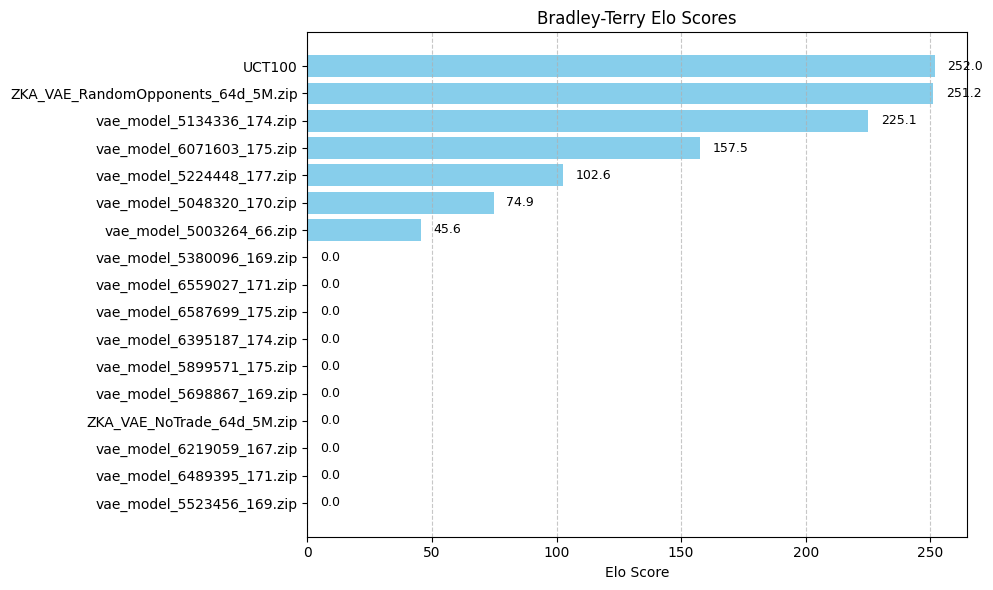

In [8]:
def plot_bt_scores(bt_scores, title="Bradley-Terry Elo Scores"):
    """
    绘制模型分数的条形图
    """
    # 按分数排序
    bt_scores_sorted = bt_scores.sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(bt_scores_sorted.index, bt_scores_sorted.values, color='skyblue')

    # 显示数值
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 5, bar.get_y() + bar.get_height()/2,
                 f'{width:.1f}', va='center', fontsize=9)

    plt.xlabel("Elo Score")
    plt.title(title)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_bt_scores(bt_scores)
